In [1]:
import galsim
from galsim import hsm
import matplotlib.pyplot as plt
import h5py
import numpy as np

0.011359140276908875 -0.010972099378705025 galsim.Shear(g1=0.005679924328008871,g2=-0.005486391810577835)


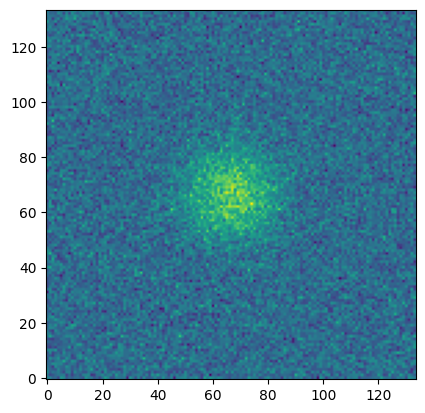

In [2]:
gal_flux = 1.e5    # total counts on the image
gal_sigma = 2.     # arcsec
psf_sigma = 1.     # arcsec
pixel_scale = 0.2  # arcsec / pixel
noise = 30.        # standard deviation of the counts in each pixel
gal = galsim.Gaussian(flux=gal_flux, sigma=gal_sigma)


psf = galsim.Gaussian(flux=1., sigma=psf_sigma) # PSF flux should always = 1
final = galsim.Convolve([gal, psf])
image = final.drawImage(scale=pixel_scale)
image.addNoise(galsim.GaussianNoise(sigma=noise))


results = image.FindAdaptiveMom()
plt.imshow(image.array,origin='lower')
print(results.observed_e1,results.observed_e2,results.observed_shape)

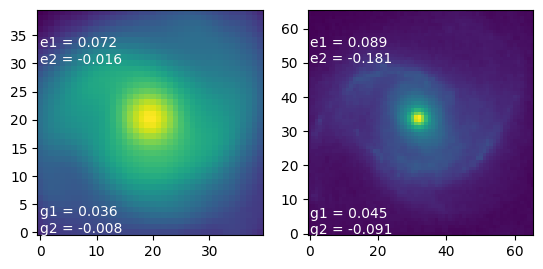

In [3]:
randind = np.random.randint(1000)
with h5py.File('../data/Nircam_train_cosmos.hdf5', 'r', swmr=True) as hr_hdf5:
    hr_image = hr_hdf5["train_img"][randind, ...]

with h5py.File('../data/Nisp_train_cosmos.hdf5', 'r', swmr=True) as lr_hdf5:
    lr_image = lr_hdf5["train_img"][randind, ...]

real_image = galsim.ImageF(40,40)
real_image.array = lr_image[0,:,:]
plt.subplot(1,2,1)
plt.imshow(real_image.array,origin='lower')
results = real_image.FindAdaptiveMom()
plt.text(0,30,"e1 = %.3f\ne2 = %.3f"%(results.observed_e1,results.observed_e2),color='white')
plt.text(0,0, "g1 = %.3f\ng2 = %.3f"%(results.observed_shape.g1,results.observed_shape.g2),color='white')


real_image = galsim.ImageF(66,66)
real_image.array = hr_image[0,:,:]
plt.subplot(1,2,2)
plt.imshow(real_image.array,origin='lower')
results = real_image.FindAdaptiveMom()
plt.text(0,50,"e1 = %.3f\ne2 = %.3f"%(results.observed_e1,results.observed_e2),color='white')
plt.text(0,0, "g1 = %.3f\ng2 = %.3f"%(results.observed_shape.g1,results.observed_shape.g2),color='white')

plt.show()

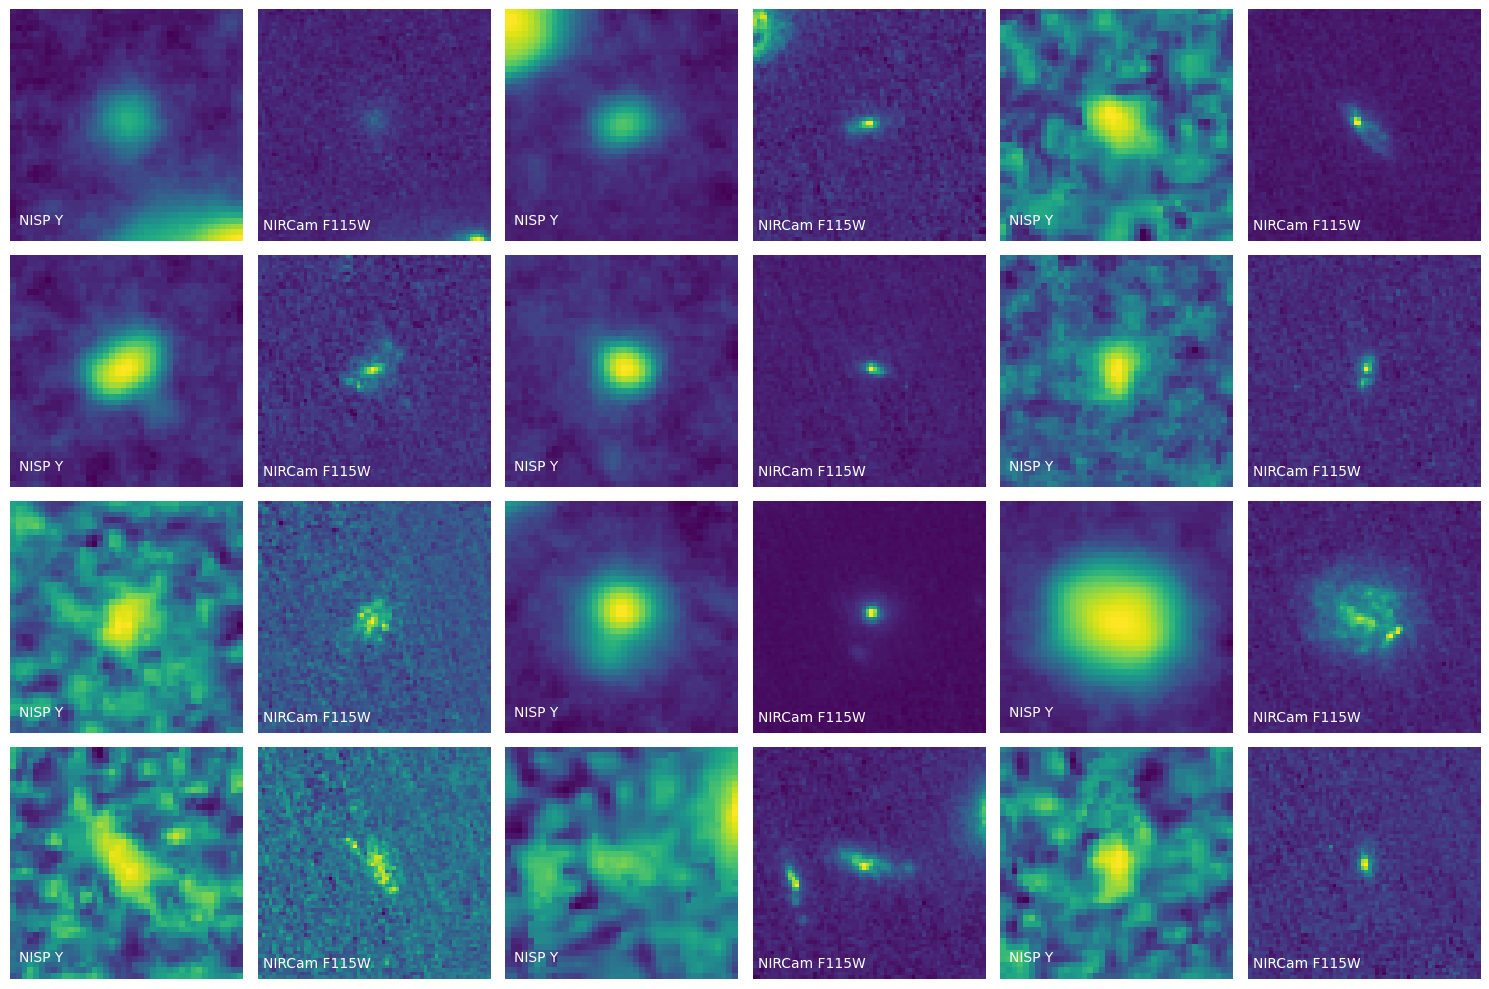

In [38]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import galsim

n_pairs = 12  # 12 pairs total (i.e., 24 images)
fig, axs = plt.subplots(4, 6, figsize=(15, 10))  # 4 rows, 6 columns (3 pairs per row)

with h5py.File('../data/Nircam_train_cosmos.hdf5', 'r', swmr=True) as hr_hdf5, \
     h5py.File('../data/Nisp_train_cosmos.hdf5', 'r', swmr=True) as lr_hdf5:

    for i in range(n_pairs):
        randind = np.random.randint(len(hr_hdf5["train_img"]))

        # Load low-res (NISP Y)
        lr_image = lr_hdf5["train_img"][randind, ...]
        lr_galsim = galsim.ImageF(40, 40)
        lr_galsim.array = lr_image[0, :, :]

        # Load high-res (NIRCam F115W)
        hr_image = hr_hdf5["train_img"][randind, ...]
        hr_galsim = galsim.ImageF(66, 66)
        hr_galsim.array = hr_image[0, :, :]

        row = i // 3
        col_offset = (i % 3) * 2  # 0, 2, 4

        # Plot NISP Y
        axs[row, col_offset].imshow(lr_galsim.array, origin='lower')
        axs[row, col_offset].axis('off')
        axs[row, col_offset].text(1, 2, "NISP Y", color='white', fontsize=10, ha='left', va='bottom')

        # Plot NIRCam F115W
        axs[row, col_offset + 1].imshow(hr_galsim.array, origin='lower')
        axs[row, col_offset + 1].axis('off')
        axs[row, col_offset + 1].text(1, 2, "NIRCam F115W", color='white', fontsize=10, ha='left', va='bottom')

plt.tight_layout()
plt.savefig('cosmos_examples.png')

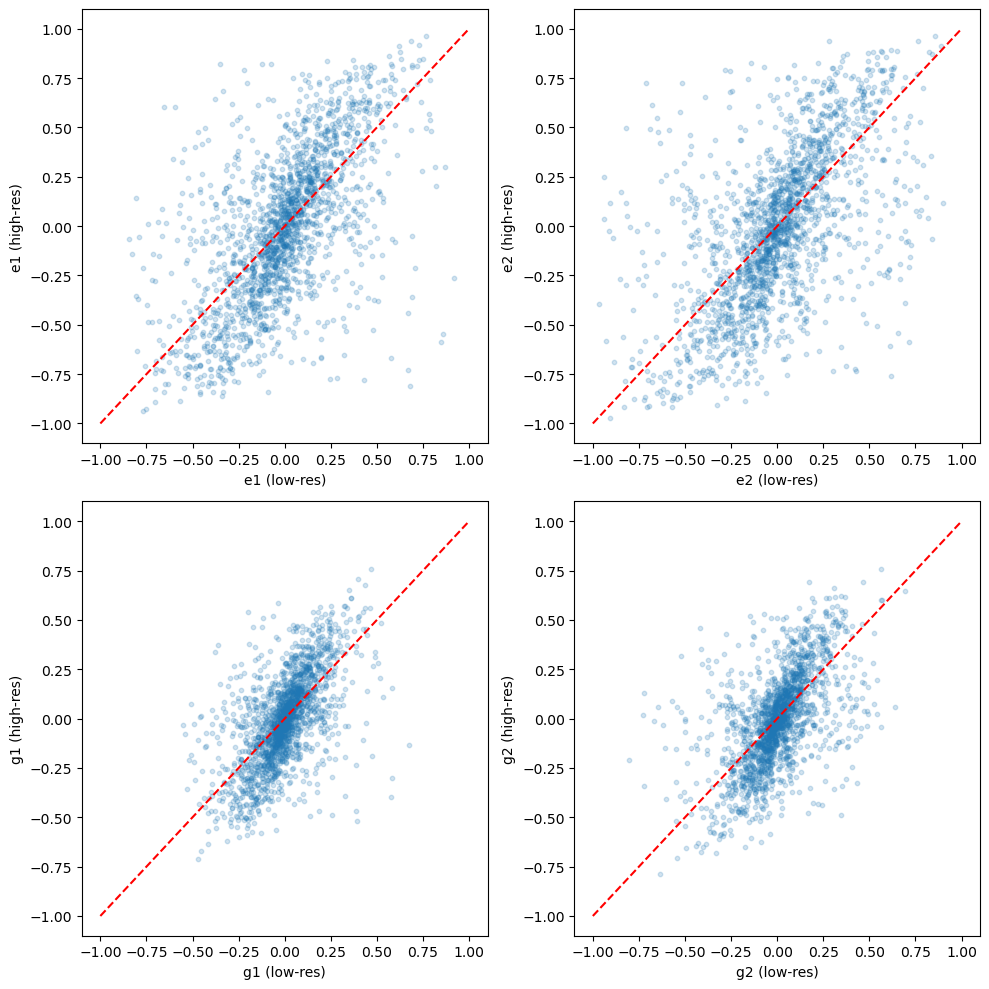

In [4]:
import numpy as np
import h5py
import galsim
import matplotlib.pyplot as plt

n_samples = 2000  # You can change this number
e1_lr, e2_lr, g1_lr, g2_lr = [], [], [], []
e1_hr, e2_hr, g1_hr, g2_hr = [], [], [], []

with h5py.File('../data/Nircam_train_cosmos.hdf5', 'r', swmr=True) as hr_hdf5, \
     h5py.File('../data/Nisp_train_cosmos.hdf5', 'r', swmr=True) as lr_hdf5:

    for i in range(n_samples):
        lr_image = lr_hdf5["train_img"][i, 0, :, :]
        hr_image = hr_hdf5["train_img"][i, 0, :, :]

        try:
            img_lr = galsim.ImageF(lr_image.shape[0], lr_image.shape[1])
            img_lr.array = lr_image
            res_lr = img_lr.FindAdaptiveMom()
            e1_lr.append(res_lr.observed_e1)
            e2_lr.append(res_lr.observed_e2)
            g1_lr.append(res_lr.observed_shape.g1)
            g2_lr.append(res_lr.observed_shape.g2)
        except:
            continue  # skip if galsim fails

        try:
            img_hr = galsim.ImageF(hr_image.shape[0], hr_image.shape[1])
            img_hr.array = hr_image
            res_hr = img_hr.FindAdaptiveMom()
            e1_hr.append(res_hr.observed_e1)
            e2_hr.append(res_hr.observed_e2)
            g1_hr.append(res_hr.observed_shape.g1)
            g2_hr.append(res_hr.observed_shape.g2)
        except:
            # Remove last appended LR values if HR fails
            e1_lr.pop(); e2_lr.pop(); g1_lr.pop(); g2_lr.pop()
            continue

# Scatter plots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].scatter(e1_lr, e1_hr, s=10, alpha=0.2)
axs[0, 0].plot([-1,1], [-1,1], 'r--')
axs[0, 0].set_xlabel("e1 (low-res)")
axs[0, 0].set_ylabel("e1 (high-res)")

axs[0, 1].scatter(e2_lr, e2_hr, s=10, alpha=0.2)
axs[0, 1].plot([-1,1], [-1,1], 'r--')
axs[0, 1].set_xlabel("e2 (low-res)")
axs[0, 1].set_ylabel("e2 (high-res)")

axs[1, 0].scatter(g1_lr, g1_hr, s=10, alpha=0.2)
axs[1, 0].plot([-1,1], [-1,1], 'r--')
axs[1, 0].set_xlabel("g1 (low-res)")
axs[1, 0].set_ylabel("g1 (high-res)")

axs[1, 1].scatter(g2_lr, g2_hr, s=10, alpha=0.2)
axs[1, 1].plot([-1,1], [-1,1], 'r--')
axs[1, 1].set_xlabel("g2 (low-res)")
axs[1, 1].set_ylabel("g2 (high-res)")

plt.tight_layout()
plt.show()
